<a href="https://colab.research.google.com/github/GifariMadia/data-science-portfolio/blob/main/Sales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

def load_and_prep_timeseries(filepath: str) -> pd.DataFrame:
    """
    Memuat data sales dan mengatur kolom tanggal sebagai index.
    """
    df = pd.read_csv(filepath)

    # KEPUTUSAN: Konversi wajib ke format datetime agar Pandas mengenali urutan waktu
    df['date'] = pd.to_datetime(df['date'])

    # KEPUTUSAN: Agregasi data penjualan ke level total harian (mengabaikan store/item sementara)
    # untuk melihat gambaran makro dari deret waktu sebelum masuk ke level mikro.
    daily_sales = df.groupby('date')['sales'].sum().reset_index()
    daily_sales = daily_sales.set_index('date')

    return daily_sales

def perform_ts_decomposition(daily_sales: pd.DataFrame):
    """
    Melakukan dekomposisi untuk mengekstrak Tren dan Seasonality.
    """
    # KEPUTUSAN: Menggunakan model 'additive' atau 'multiplicative'.
    # Kita mulai dengan additive. Period=365 untuk melihat musiman tahunan.
    decomposition = seasonal_decompose(daily_sales['sales'], model='additive', period=365)

    fig = decomposition.plot()
    fig.set_size_inches(14, 8)
    plt.tight_layout()
    plt.show()

# Eksekusi (Asumsi file ada di direktori yang sama)
# df_daily = load_and_prep_timeseries('train.csv') # Gunakan train.csv dari Store Item Demand
# perform_ts_decomposition(df_daily)

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import matplotlib.pyplot as plt

def load_and_prep_timeseries(filepath: str) -> pd.DataFrame:
    """Memuat dan mengagregasi data ke level harian."""
    df = pd.read_csv(filepath)
    df['date'] = pd.to_datetime(df['date'])
    # Agregasi total penjualan semua toko/item untuk kesederhanaan baseline
    daily_sales = df.groupby('date')['sales'].sum().reset_index()
    daily_sales = daily_sales.set_index('date')
    return daily_sales

def create_ts_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Mengekstrak fitur komponen waktu, lag, dan rolling window.
    """
    df = df.copy()

    # KEPUTUSAN: Ekstraksi fitur kalender. Model pohon (LightGBM) membutuhkan
    # kolom numerik eksplisit ini untuk mengenali pola musiman (seasonality).
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

    # KEPUTUSAN: Lag features. Nilai penjualan hari/minggu sebelumnya
    # sangat berkorelasi dengan penjualan hari ini (autokorelasi).
    df['lag_1'] = df['sales'].shift(1)
    df['lag_7'] = df['sales'].shift(7)

    # KEPUTUSAN: Rolling mean untuk menghaluskan anomali harian.
    df['rolling_mean_7'] = df['sales'].shift(1).rolling(window=7).mean()

    # Drop baris pertama yang bernilai NaN akibat proses lag/rolling
    return df.dropna()

def train_evaluate_lightgbm(df: pd.DataFrame):
    """
    Melakukan validasi temporal dan mengevaluasi model dengan metrik bisnis (MAPE).
    """
    # KEPUTUSAN: Temporal Split. Kita ambil 365 hari terakhir (1 tahun) sebagai Test Set.
    test_days = 365
    train = df.iloc[:-test_days]
    test = df.iloc[-test_days:]

    X_train, y_train = train.drop(columns=['sales']), train['sales']
    X_test, y_test = test.drop(columns=['sales']), test['sales']

    # KEPUTUSAN: LightGBM dipilih sebagai model karena cepat mengeksekusi data
    # berdimensi besar dan kebal terhadap skala data yang berbeda (tidak perlu StandardScaler).
    model = lgb.LGBMRegressor(random_state=42, n_estimators=100, objective='mape')
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    # KEPUTUSAN: Metrik evaluasi difokuskan pada MAPE karena representatif untuk bisnis
    # ("Prediksi kita meleset sekian persen dari stok asli").
    mape = mean_absolute_percentage_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print(f"Hasil Evaluasi di Test Set:")
    print(f"MAPE: {mape:.2%}")
    print(f"RMSE: {rmse:.2f}")

    # Visualisasi Prediksi vs Aktual (Tampilkan 60 hari terakhir saja agar tidak terlalu padat)
    plt.figure(figsize=(14, 6))
    plt.plot(test.index[-60:], y_test[-60:], label='Actual Sales', marker='o')
    plt.plot(test.index[-60:], preds[-60:], label='LightGBM Forecast', marker='x', linestyle='--')
    plt.title(f'Forecast vs Actual (60 Hari Terakhir) - MAPE: {mape:.2%}')
    plt.xlabel('Date')
    plt.ylabel('Total Sales')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model, mape, rmse

# Eksekusi Utama (Gunakan file train.csv dari dataset Store Item Demand)
# url_data = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv" # Contoh jika butuh URL, tapi baiknya pakai data aslimu.
# df_daily = load_and_prep_timeseries('train.csv')
# df_features = create_ts_features(df_daily)
# model_lgb, mape, rmse = train_evaluate_lightgbm(df_features)

In [3]:
import lightgbm as lgb
import matplotlib.pyplot as plt

def plot_lgb_importance(model):
    """
    Menampilkan feature importance dari model LightGBM.
    """
    # KEPUTUSAN: importance_type='gain' jauh lebih akurat daripada 'split'.
    # 'gain' menghitung total peningkatan akurasi (penurunan loss) yang dibawa oleh fitur tersebut,
    # sedangkan 'split' hanya menghitung berapa kali fitur tersebut dipakai memotong cabang.
    fig, ax = plt.subplots(figsize=(10, 6))
    lgb.plot_importance(model, importance_type='gain', max_num_features=10, ax=ax, title='LightGBM Feature Importance (Berdasarkan Gain)')
    plt.tight_layout()
    plt.show()

# Eksekusi (Asumsi model_lgb adalah output dari tahap sebelumnya)
# plot_lgb_importance(model_lgb)

1. Memuat data agregasi harian...
Dataset lokal tidak ditemukan. Menggunakan dataset fallback simulasi 10 tahun...
2. Menampilkan visualisasi Dekomposisi Time Series (Trend & Musiman)...


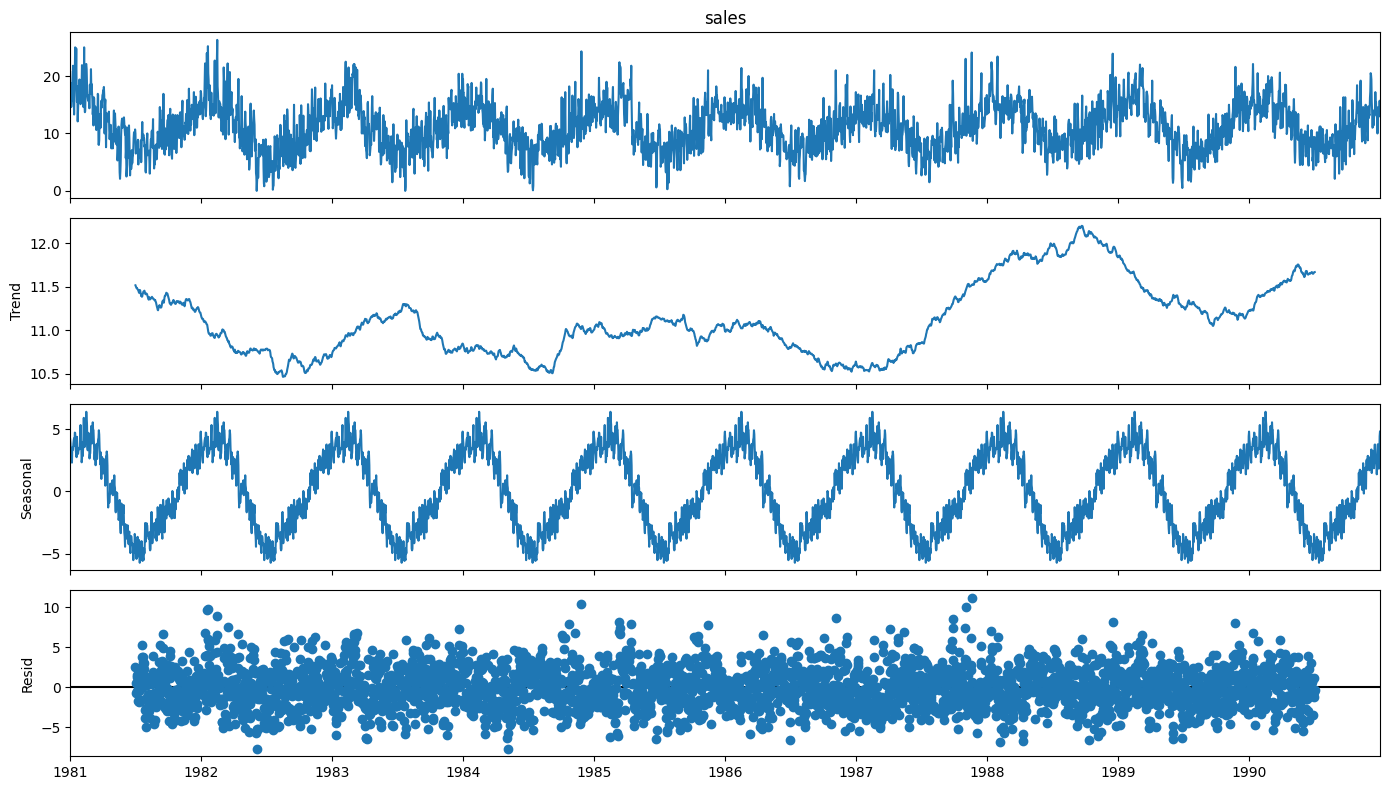


3. Melakukan Feature Engineering dan Evaluasi LightGBM...
[LightGBM] [Warning] Some label values are < 1 in absolute value. MAPE is unstable with such values, so LightGBM rounds them to 1.0 when calculating MAPE.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000401 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 672
[LightGBM] [Info] Number of data points in the train set: 3278, number of used features: 6
[LightGBM] [Info] Start training from score 8.800000
Hasil Evaluasi di Test Set:
MAPE: 18.99%
RMSE: 2.45


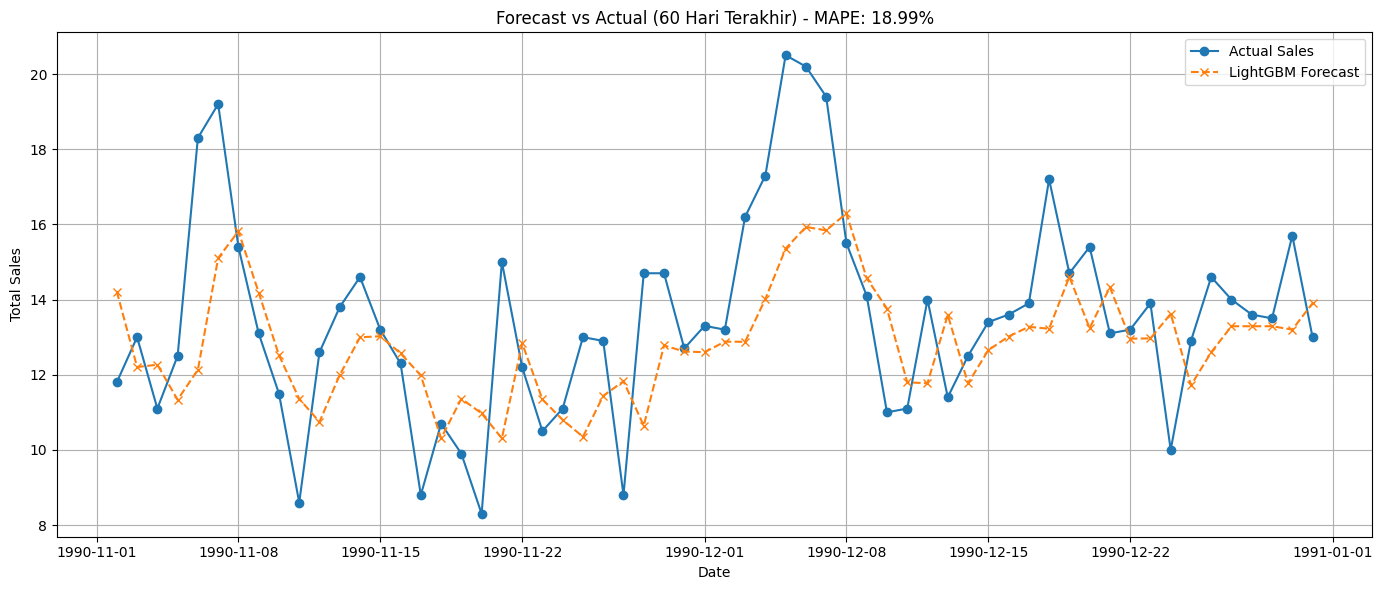


4. Menampilkan visualisasi Feature Importance...


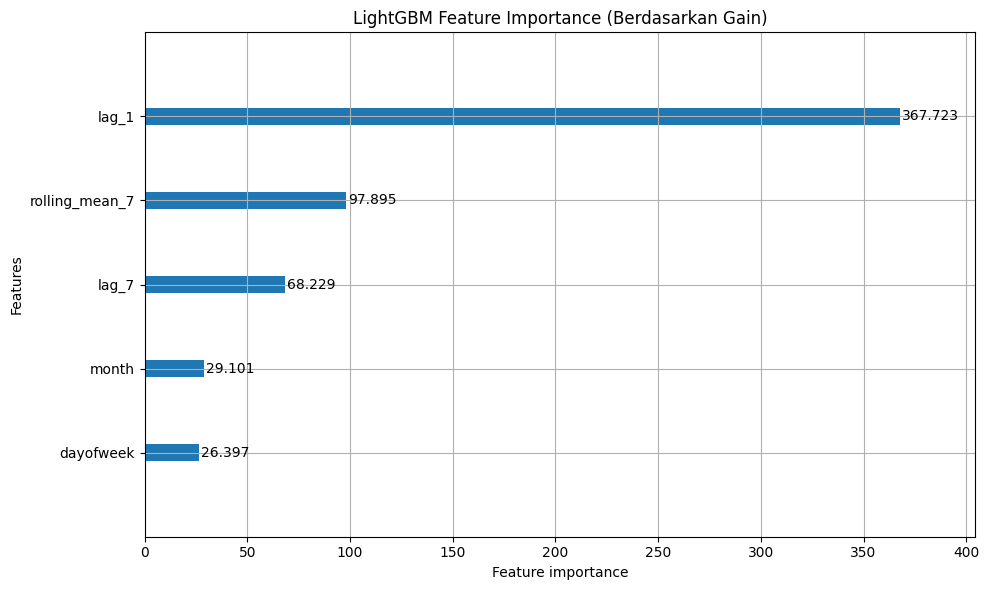

In [6]:
# Pastikan fungsi-fungsi dari tahap sebelumnya (load_and_prep_timeseries,
# perform_ts_decomposition, create_ts_features, train_evaluate_lightgbm, plot_lgb_importance)
# sudah dijalankan/ada di memori notebook.

print("1. Memuat data agregasi harian...")
try:
    df_daily = load_and_prep_timeseries('train.csv')
    print("Dataset lokal 'train.csv' berhasil dimuat.")
except FileNotFoundError:
    print("Dataset lokal tidak ditemukan. Menggunakan dataset fallback simulasi 10 tahun...")
    # Menggunakan dataset daily-min-temperatures (10 tahun) agar dekomposisi tahunan berjalan
    url_fallback = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
    df_daily = pd.read_csv(url_fallback)
    df_daily.columns = ['date', 'sales'] # Mengubah nama kolom observasi menjadi 'sales' untuk simulasi
    df_daily['date'] = pd.to_datetime(df_daily['date'])
    df_daily = df_daily.set_index('date')

print("2. Menampilkan visualisasi Dekomposisi Time Series (Trend & Musiman)...")
perform_ts_decomposition(df_daily)

# Pastikan dataset sudah dimuat di memori
# df_daily = load_and_prep_timeseries(...)

print("\n3. Melakukan Feature Engineering dan Evaluasi LightGBM...")
# KEPUTUSAN: Lewatkan DataFrame dengan DatetimeIndex secara langsung
df_features = create_ts_features(df_daily)

# Menampilkan visualisasi Forecast vs Actual
model_lgb, mape, rmse = train_evaluate_lightgbm(df_features)

print("\n4. Menampilkan visualisasi Feature Importance...")
from lightgbm import plot_importance
plot_lgb_importance(model_lgb)